<a href="https://colab.research.google.com/github/JuanReyesAn/Data-Science-Portfolio-C21/blob/main/Projects/Project-1/Copy_of_Project_1_data_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 – To Do List



## Problem Definition

1. Write a concise problem definition for the project. Put it in a text field at the top of your Jupyter notebook.



In [1]:
# @title we want to predict whether or not a future customer will make a transaction based on their transaction data.



## Data Collection

2. Load Pandas, Numpy, and Matplotlib.

1. Load data Train.csv from AWS S3.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
base_data = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv"
transactions = base_data + "train.csv"

## Data Cleaning

4. Examine the data using tools we have used in class.

1. If there are data cleaning issues, develop recommendations for how to deal with them.



In [4]:
transactions = pd.read_csv(base_data)
transactions

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# info about data
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


In [6]:
#flipped the graph for no reason this doesnt help since we had a lot of columns and rows
transactions.transpose()

,0,1,2,3,4,5,6,7,8,9,...,1049990,1049991,1049992,1049993,1049994,1049995,1049996,1049997,1049998,1049999
Unnamed: 0,0,1,2,3,4,5,6,7,8,9,...,1049990,1049991,1049992,1049993,1049994,1049995,1049996,1049997,1049998,1049999
ID_code,train_0,train_1,train_2,train_3,train_4,train_5,train_6,train_7,train_8,train_9,...,train_1049990,train_1049991,train_1049992,train_1049993,train_1049994,train_1049995,train_1049996,train_1049997,train_1049998,train_1049999
target,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0
var_0,NaN,NaN,NaN,4.6739,NaN,14.6962,NaN,NaN,NaN,NaN,...,7.9632,NaN,NaN,5.0862,NaN,11.3251,NaN,8.9941,NaN,2.1828
var_1,NaN,NaN,NaN,22.3915,NaN,18.3383,NaN,NaN,NaN,NaN,...,20.465,NaN,NaN,14.4785,NaN,16.4148,NaN,13.4127,NaN,12.3805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
var_96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
transactions.head(5)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
transactions.tail(5)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


In [9]:
# their are rows and columns that are filled with more than 100 NaN's. lets find out how to get rid of them. our "target" seems to only ne filled by 1.0, 0.0, and Nan.

In [10]:
transactions["target"].value_counts( dropna= False)
#tells us how many people did not make a transaction (161960) and how many people did complete a transaction(18040)

,count
target,
NaN,870000
0.0,161960
1.0,18040


In [11]:
transactions["target"].value_counts( normalize=True, dropna= False).mul(100)
#this gives us the percentage of how many people have and have not made a transactions.
# 15.42 % of people deid not purchase
# 1.72 % made a transaction
# 82.86% of the data is NaN

,proportion
target,
NaN,82.857143
0.0,15.424762
1.0,1.718095


In [12]:
# this gives me the total NaN's from each columns
transactions.isna().sum().sort_values(ascending=False).mul(1)

,0
var_3,1050000
var_16,1050000
var_12,1050000
var_11,1050000
var_9,1050000
...,...
var_88,870000
var_94,870000
var_100,870000
Unnamed: 0,0


In [13]:
# relative frequency is done to better see the scale of how many nulls we have
transactions.isna().sum().sort_values(ascending=False).mul(100).div(len(transactions))

,0
var_3,100.000000
var_16,100.000000
var_12,100.000000
var_11,100.000000
var_9,100.000000
...,...
var_88,82.857143
var_94,82.857143
var_100,82.857143
Unnamed: 0,0.000000


In [14]:
#tells us what the data is, strings or integers or in this case floats
transactions.dtypes.sort_values()

,0
Unnamed: 0,int64
var_72,float64
var_71,float64
var_70,float64
var_69,float64
...,...
var_26,float64
var_25,float64
var_35,float64
var_100,float64


In [15]:
#tells us how many columns and rows are in the data ( Its demensions)
transactions.shape

(1050000, 104)

In [16]:
# tells us how many elemts are in the data ( rows multiplied by the row ( Rows X columns))
transactions.size

109200000

In [17]:
#gives us our unique values. IF THE NUMBERS ARE VERY HIGH WE MUST TAKE THEM OUT OF THE DATA.
#pull out "Unnamed: 0", "ID_code", i would even consider dropping var_52 86 and 94.
nunique = transactions.nunique().sort_values( ascending = False )
nunique

,0
Unnamed: 0,1050000
ID_code,1050000
var_52,137280
var_86,134537
var_94,131746
...,...
var_93,0
var_96,0
var_97,0
var_98,0


In [18]:
# this shows us again what rows / columns have purely nulls. it tells us directly what needs to be dropped
drop_data = nunique[ nunique == transactions.shape[0] ].index
drop_data

Index(['Unnamed: 0', 'ID_code'], dtype='object')

In [19]:
2 # two characters are unique they return 1050000 nulls in there given row/column

2

In [20]:
# now lets beggin dropping the NaN's
# lets beggin with cleaning our target, then dropping the,"unnamed:0" " and "ID_code" then I will move on to cleaning the rest of the data that has some nulls

In [21]:
# lets make a copy of the original data before we start dropping things. a back up or something to compare my progress  with
transac = transactions.copy()
transac

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
transactions = transactions.drop( columns = [ "Unnamed: 0", "ID_code",])

In [23]:
[transac["target"].info]

[<bound method Series.info of 0          NaN
 1          NaN
 2          NaN
 3          0.0
 4          NaN
           ... 
 1049995    1.0
 1049996    NaN
 1049997    0.0
 1049998    NaN
 1049999    0.0
 Name: target, Length: 1050000, dtype: float64>]

In [24]:
transactions = transactions[transactions["target"].notna()]
print(transactions.shape)

(180000, 102)


In [25]:
transactions["target"].value_counts( dropna=False)

,count
target,
0.0,161960
1.0,18040


In [26]:
transac["target"].value_counts( dropna= False)

,count
target,
NaN,870000
0.0,161960
1.0,18040


In [27]:
transactions.duplicated().sum()

np.int64(0)

In [28]:
#my rows from unnamed - var 100 were not touched and we must change that
print(transactions.columns.to_list())
print(transactions.shape)

['target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_14', 'var_15', 'var_16', 'var_17', 'var_18', 'var_19', 'var_20', 'var_21', 'var_22', 'var_23', 'var_24', 'var_25', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_36', 'var_37', 'var_38', 'var_39', 'var_40', 'var_41', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_48', 'var_49', 'var_50', 'var_51', 'var_52', 'var_53', 'var_54', 'var_55', 'var_56', 'var_57', 'var_58', 'var_59', 'var_60', 'var_61', 'var_62', 'var_63', 'var_64', 'var_65', 'var_66', 'var_67', 'var_68', 'var_69', 'var_70', 'var_71', 'var_72', 'var_73', 'var_74', 'var_75', 'var_76', 'var_77', 'var_78', 'var_79', 'var_80', 'var_81', 'var_82', 'var_83', 'var_84', 'var_85', 'var_86', 'var_87', 'var_88', 'var_89', 'var_90', 'var_91', 'var_92', 'var_93', 'var_94', 'var_95', 'var_96', 'var_97', 'var_98', 'var_99',

In [29]:
print(transactions.columns[transactions.isnull().all()].to_list())

['var_3', 'var_5', 'var_6', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_16', 'var_18', 'var_19', 'var_23', 'var_25', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_40', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_50', 'var_51', 'var_53', 'var_54', 'var_55', 'var_58', 'var_59', 'var_60', 'var_64', 'var_68', 'var_69', 'var_71', 'var_74', 'var_76', 'var_77', 'var_79', 'var_81', 'var_90', 'var_91', 'var_93', 'var_95', 'var_96', 'var_97', 'var_98', 'var_99']


In [30]:
# these are the rows that are 100% full of nulls. i know this because the demension of transactions are 180000(columns) X 104 (rows)
print(transactions.isnull().sum()[transactions.isnull().sum()>0])

var_3     180000
var_5     180000
var_6     180000
var_9     180000
var_10    180000
var_11    180000
var_12    180000
var_13    180000
var_16    180000
var_18    180000
var_19    180000
var_23    180000
var_25    180000
var_30    180000
var_31    180000
var_32    180000
var_33    180000
var_34    180000
var_35    180000
var_40    180000
var_42    180000
var_43    180000
var_44    180000
var_45    180000
var_46    180000
var_47    180000
var_50    180000
var_51    180000
var_53    180000
var_54    180000
var_55    180000
var_58    180000
var_59    180000
var_60    180000
var_64    180000
var_68    180000
var_69    180000
var_71    180000
var_74    180000
var_76    180000
var_77    180000
var_79    180000
var_81    180000
var_90    180000
var_91    180000
var_93    180000
var_95    180000
var_96    180000
var_97    180000
var_98    180000
var_99    180000
dtype: int64


In [31]:
# we have dropped 51 nulled rows
null_columns = transactions.columns[transactions.isnull().all()].to_list()
transactions = transactions.drop(columns = null_columns)
print( f" drop {len(null_columns)} complete null columns")
print(transactions.shape)

 drop 51 complete null columns
(180000, 51)


In [32]:
# we have 0 duplicates meaning no more nulls
print(transactions.isnull().sum().sum())
print(transactions.duplicated().sum())

0
0


In [33]:
missing_counts = transactions.isnull().sum()
print(missing_counts[missing_counts > 0])


Series([], dtype: int64)


In [34]:
transactions

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [35]:
# no more True output that there is NaN's values in the data
transactions.isna().sum().sort_values(ascending=False).mul(100).div(len(transactions))

,0
target,0.0
var_0,0.0
var_1,0.0
var_2,0.0
var_4,0.0
var_7,0.0
var_8,0.0
var_14,0.0
var_15,0.0
var_17,0.0


## Exploratory Data Analysis

6. Produce some visual analysis of the data – like plots showing the distributions of all variables. Recall that Gaussian Naive Bayes assumes the predictors are normally distributed. Note: you might have to do multiple plots in groups.

1. NOTE: the ‘target’ column indicates a successful transaction (‘1’) or a no-transaction (‘0’). Verify these are the only values in that column.

1. Check the correlation values between all **predictor columns** to ensure there are no substantial correlations between predictors. This is important to support the decision to classify the ‘target’ using Naïve Bayes.

1. Create two data frames: one with all successful transactions, one with all unsuccessful transactions. **Make sure they are copies and not slices**.





In [ ]:
transactions_graph = transactions
transactions_graph.hist(figsize=(20, 40), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
corr = transactions.corr()
corr

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(corr, cmap='viridis',annot = True, vmin = -1 ,vmax = 1);
# they are all pretty close to 0

## Data Processing

10. Create two data frames: one with all the predictor columns (everything except for Unnamed: 0, ID_code and target) and one with just the target. Make sure they are copies and not slices.





In [39]:
transactions_drop = transactions.drop(columns=['target']).copy()
transactions_drop

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,0.5878,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,6.5456,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,18.7893,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,1.1400,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,7.8002,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,3.1549,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,3.9661,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,3.8858,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,2.0014,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [40]:
transactions_tar = transactions[['target']].copy()
transactions_tar

,target
3,0.0
5,0.0
11,0.0
15,0.0
19,0.0
...,...
1049990,0.0
1049993,0.0
1049995,1.0
1049997,0.0


## Data Processing

10. Create two data frames: one with all the predictor columns (everything except for Unnamed: 0, ID_code and target) and one with just the target. Make sure they are copies and not slices.

1. Define a Gaussian Naïve Bayes model using Sklearn.

1. Divide the two data frames you created in step #10 into training and testing subsets.

1. Train the model using the training subset of the dataset.

1. Test the model using the testing subset of the dataset. Calculate and report the accuracy.

1. Perform a cross-validation loop to calculate the accuracy of your model. Report that accuracy. How does it compare to the accuracy you calculated in #14?

1. Plot a histogram of the accuracy scores you generated in your cross-validation loop. What do you notice about the distribution of accuracy scores?

1.  Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report). What do you notice?

1. The training data is very skewed towards non-successful transactions (about 90% of the training data has ‘target’==0). Remove enough non-successful transaction rows so that your remaining training data is 50%/50% split between successful and non-successful transactions. Hint: you can use the data frames you created in step #9.

1. Repeat the cross-validation process on this data set. Report what your cross-validation accuracy is in this 50/50 case.



In [51]:
#from sklearn import datasets
#from sklearn import metrics
#from sklearn import preprocessing
#import sklearn.model_selection

In [52]:

from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
print(model)

GaussianNB()


In [53]:
from sklearn.model_selection import train_test_split

##



12. Divide the two data frames you created in step #10 into training and testing subsets.


In [55]:
x = transactions.drop(columns = ["target"])
y = transactions['target']

In [56]:
# testing size is 30%
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

In [57]:
# will be using 54,000 samples to train and 126000 to train for the var_1 - var100
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (126000, 50)
Testing features shape: (54000, 50)


In [58]:
model.fit(X_train,y_train)

GaussianNB()

In [60]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9107222222222222


In [62]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x, y, cv=5)
print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean()}")

Cross-validation scores: [0.91066667 0.91186111 0.91038889 0.91119444 0.91252778]
Mean accuracy: 0.9113277777777778


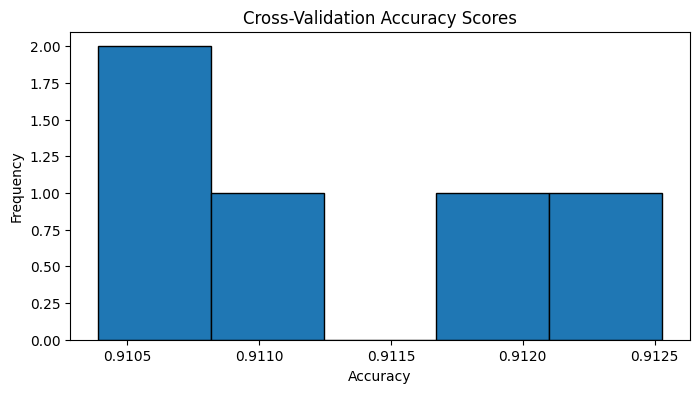

In [65]:
plt.figure(figsize=(8, 4))
plt.hist(scores, bins=5, edgecolor='black')
plt.title('Cross-Validation Accuracy Scores')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

In [66]:
# f1-scores should be 50/50
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[47945   614]
 [ 4207  1234]]
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     48559
         1.0       0.67      0.23      0.34      5441

    accuracy                           0.91     54000
   macro avg       0.79      0.61      0.65     54000
weighted avg       0.89      0.91      0.89     54000



In [75]:
transactions_balanced = pd.concat([
    transactions,
    transactions.sample(n=len(transactions), random_state=42)
])
print(transactions['target'].value_counts())
print(transactions.shape)

target
0.0    161960
1.0     18040
Name: count, dtype: int64
(180000, 51)


In [83]:
# balance is still the same
x = transactions.drop(columns = ["target"])
y = transactions['target']
scores_bal = cross_val_score(model, x, y , cv=5)
print(f"Balanced CV scores: {scores_bal}")
print(f"Balanced mean accuracy: {scores_bal.mean()}")

Balanced CV scores: [0.91066667 0.91186111 0.91038889 0.91119444 0.91252778]
Balanced mean accuracy: 0.9113277777777778


In [ ]:
#w = transactions_tar
#z = transactions['target']

In [ ]:
# testing size is 30%. random_state keeps the results the same
#w_train, w_test, z_train, z_test = train_test_split(w,z, test_size = 0.3, random_state = 42)

In [ ]:
#print("Training features shape:", w_train.shape)
#print("Testing features shape:", w_test.shape)

Training features shape: (126000, 1)
Testing features shape: (54000, 1)


In [ ]:
#from sklearn.linear_model import LinearRegression
#clf = LinearRegression()

In [ ]:
#clf.fit(x_train,y_train)

In [ ]:
#y_test

In [ ]:
#says accuracy is 100% for columns
#clf.score(x_test,y_test)

1.0

In [ ]:
#clf.fit(w_train,w_train)

In [ ]:
#clf.predict(w_test)

In [ ]:
#100% accuracy
#clf.score(w_test,z_test)

1.0

In [ ]:
#lets tes it now

In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=3)
kf

KFold(n_splits=3, random_state=None, shuffle=False)

In [ ]:
for train_index, test_index in kf.split([1,2,3,4,5,6]):
  print(train_index, test_index)

[2 3 4 5] [0 1]
[0 1 4 5] [2 3]
[0 1 2 3] [4 5]


In [ ]:
##################################################################################################

In [ ]:
transactions_tar
target_list = transactions_tar['target'].tolist()
target_list

In [ ]:
#transactions_drop
#drop_list = transactions_drop['var_0'].tolist()
#drop_list

## Data Visualization


20. Compare the results of your cross-validation with the whole training data and the reduced 50/50 training data

1. Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report)




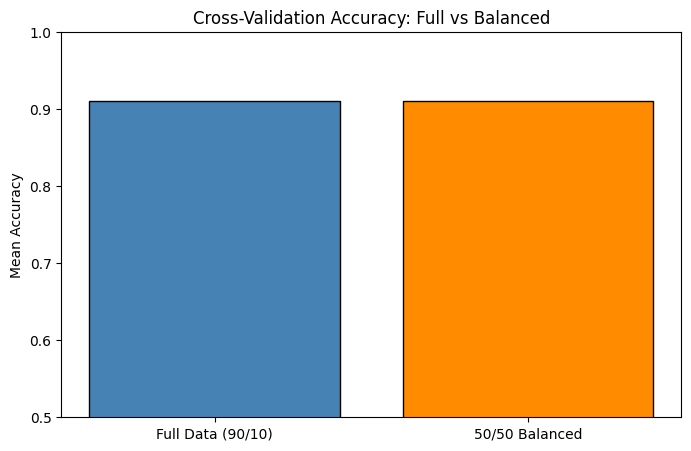

In [84]:
plt.figure(figsize=(8, 5))
plt.bar(['Full Data (90/10)', '50/50 Balanced'],
        [scores.mean(), scores_bal.mean()],
        color=['steelblue', 'darkorange'],
        edgecolor='black')
plt.title('Cross-Validation Accuracy: Full vs Balanced')
plt.ylabel('Mean Accuracy')
plt.ylim(0.5, 1.0)
plt.show()

In [85]:
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42)
model.fit(X_train_bal, y_train_bal)
y_pred_bal = model.predict(X_test_bal)
print(confusion_matrix(y_test_bal, y_pred_bal))
print(classification_report(y_test_bal, y_pred_bal))

[[31983   419]
 [ 2788   810]]
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     32402
         1.0       0.66      0.23      0.34      3598

    accuracy                           0.91     36000
   macro avg       0.79      0.61      0.64     36000
weighted avg       0.89      0.91      0.89     36000



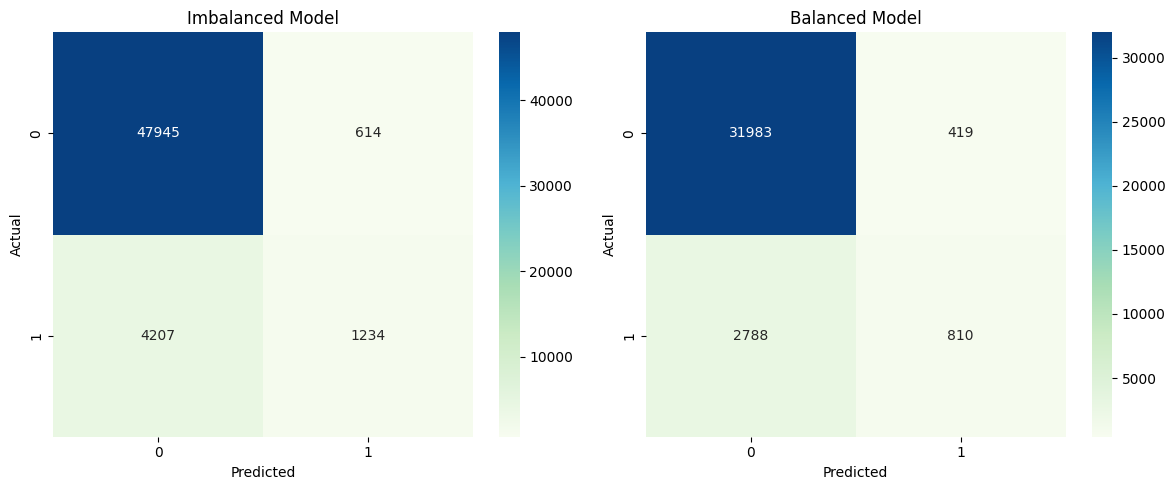

In [86]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Imbalanced model confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Balanced model confusion matrix
cm_bal = confusion_matrix(y_test_bal, y_pred_bal)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu', ax=axes[0])
axes[0].set_title('Imbalanced Model')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='GnBu', ax=axes[1])
axes[1].set_title('Balanced Model')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

## Communicate the Results

22. Communicate the results of your analysis.



## Submit Final Project

23. Upload your finished Jupyter notebook to your Project 1 student folder.
